# Notebook for the decision tree task

In [1]:
# imports

import matplotlib.pyplot as plt
import numpy as np

# Import Pandas and NumPy functionality for editing data
import pandas as pd
import seaborn as sns

# Importing IPython display for visualizing intermediate results in the notebook
from IPython.display import display

# decision tree
from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder

Load the train and test data sets

In [2]:
train_dataset_oh = pd.read_csv('./train_insurance_one_hot.csv')
x_train = train_dataset_oh.drop(columns=['id','charges','chargeGroup'], inplace=False)
y_train = train_dataset_oh[["chargeGroup"]]

test_dataset_oh = pd.read_csv('./test_insurance_one_hot.csv')
x_test = test_dataset_oh.drop(columns=['id','charges','chargeGroup'], inplace=False)
y_test = test_dataset_oh[["chargeGroup"]]

## a)

In [3]:
from sklearn.metrics import accuracy_score
y_true = test_dataset_oh['chargeGroup']
y_pred = np.full(len(test_dataset_oh), 'low')
print(f'Accuracy of prediction : {accuracy_score(y_true, y_pred):.2f}.')

Accuracy of prediction : 0.49.


## b)

In [4]:
trainingdata_chargeGroup_mode =  train_dataset_oh['chargeGroup'].mode()[0]
total_num_rows_of_mode = train_dataset_oh.loc[train_dataset_oh['chargeGroup'] == trainingdata_chargeGroup_mode].shape[0]
print(f'Portion of mode in training set : {total_num_rows_of_mode/train_dataset_oh.shape[0]:.2f}.')
correct_num = test_dataset_oh.loc[test_dataset_oh['chargeGroup'] == trainingdata_chargeGroup_mode].shape[0]
print(f'Accuracy of prediction : {correct_num/test_dataset_oh.shape[0]:.2f}.')

Portion of mode in training set : 0.48.
Accuracy of prediction : 0.39.


## c)

'Highest accuracy : 0.94.'

Text(0, 0.5, 'Accuracy')

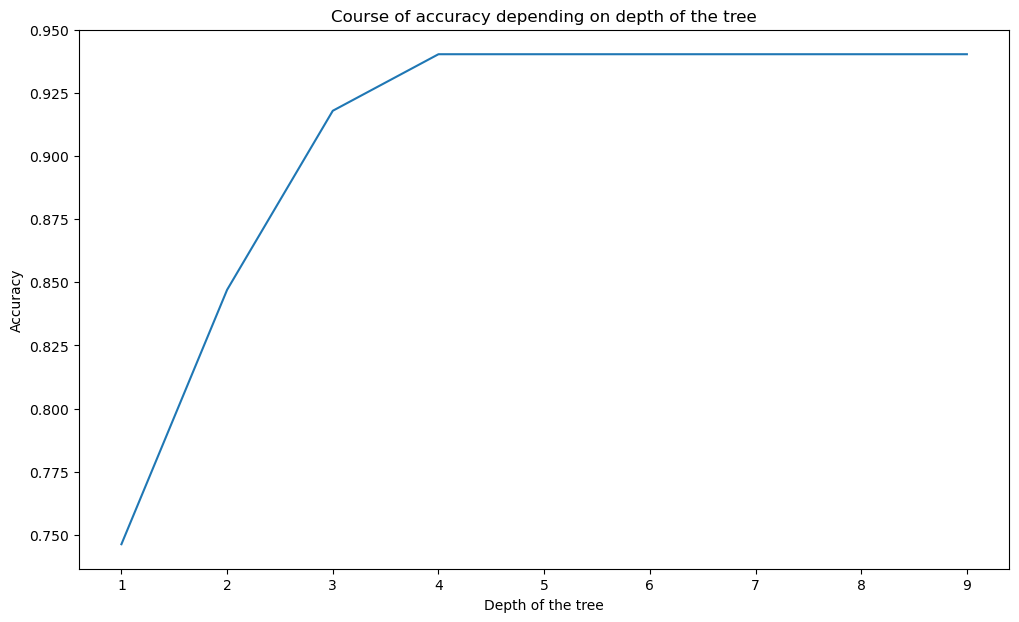

In [5]:
from sklearn import metrics
max_depths = range(1,10)
accuracy_value =[]
for depth in max_depths:

    model = tree.DecisionTreeClassifier(criterion='entropy', min_samples_leaf=6, random_state=42,max_depth=depth)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy_value.append(metrics.accuracy_score(y_test, y_pred))
display(f'Highest accuracy : {max(accuracy_value):.2f}.')
fig = plt.figure(figsize=(12,7))
plt.plot(max_depths, accuracy_value)
plt.title("Course of accuracy depending on depth of the tree")
plt.xlabel("Depth of the tree")
plt.ylabel("Accuracy")


## d)

Predicted class: low.


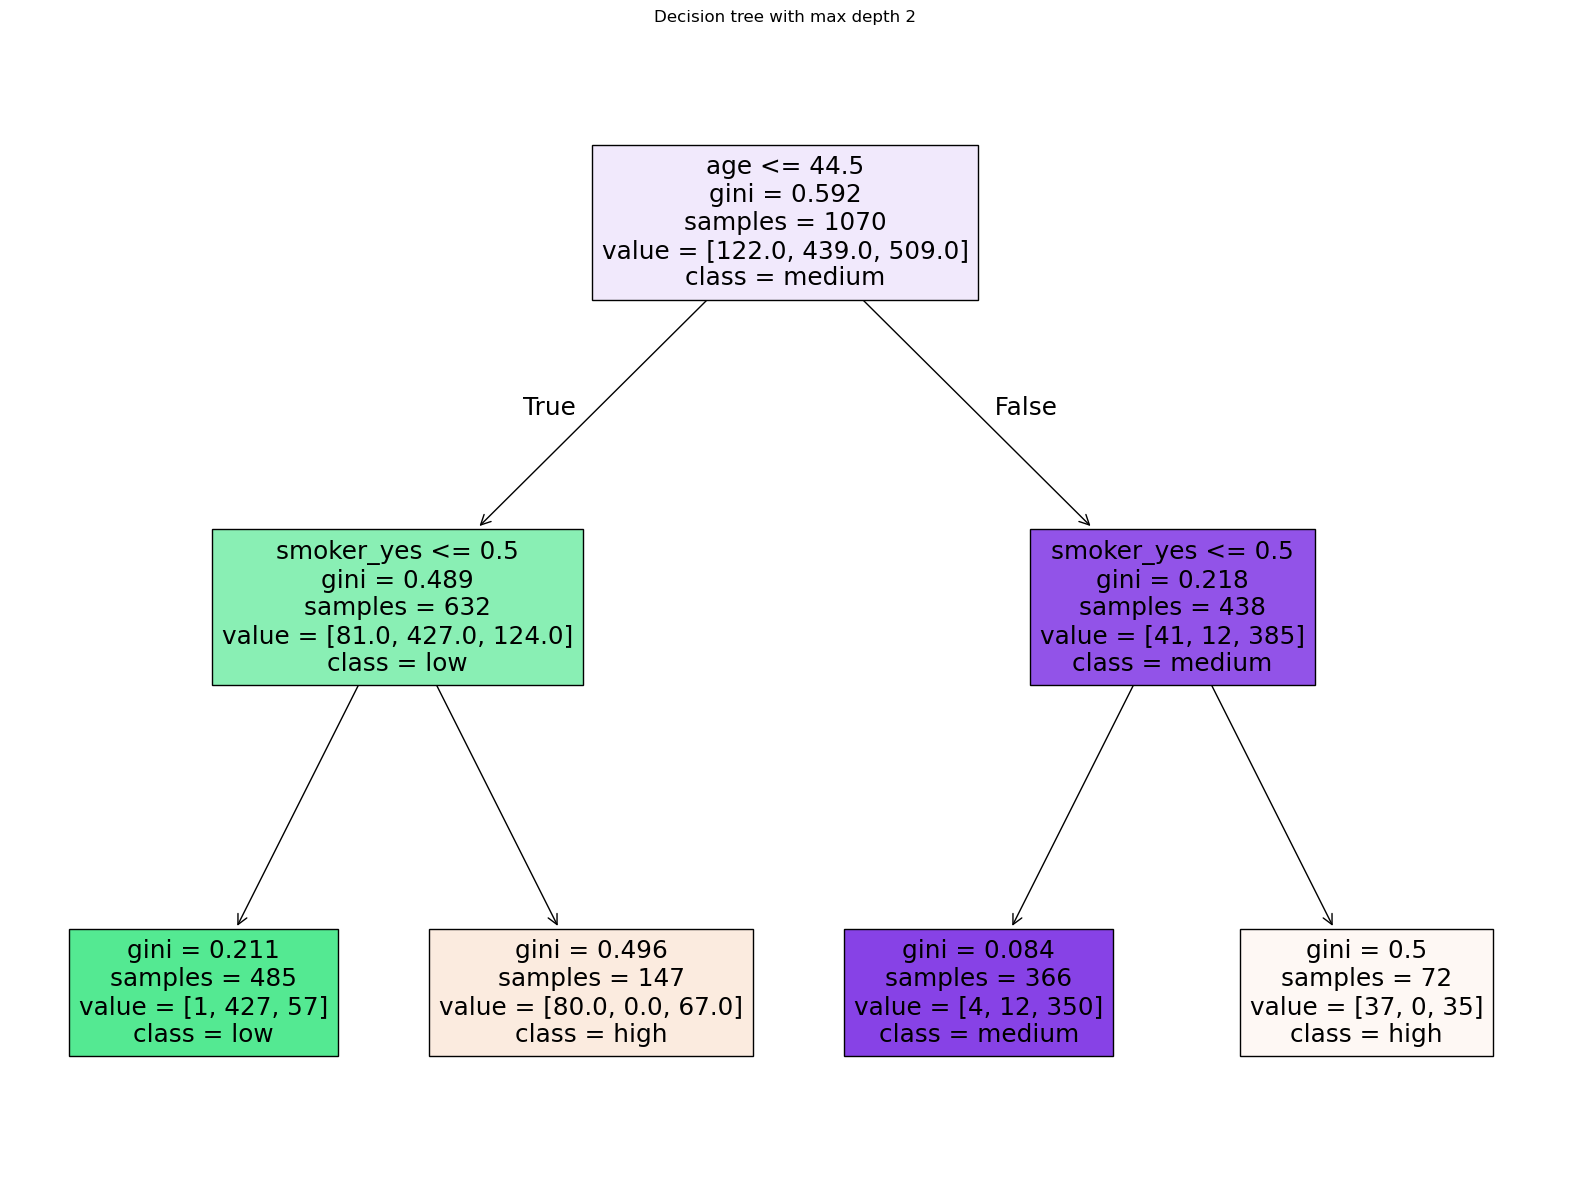

In [6]:
model = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=6, random_state=42,max_depth=2)

model.fit(x_train, y_train)
fig = plt.figure(figsize=(20,15))
tree.plot_tree(model,
               feature_names=x_train.columns,class_names=model.classes_,filled=True)
plt.title("Decision tree with max depth 2")
x_test_ = pd.DataFrame({
    'age': [42],
    'bmi': [36],
    'children': [2],
    'sex_female':False,
    'sex_male':True,
    'smoker_no':True,
    'smoker_yes':False,
    'region_northeast': False,
    'region_northwest': True,
    'region_southeast': False,
    'region_southwest': False,
})
y_pred_ = model.predict(x_test_)
print(f'Predicted class: {y_pred_[0]}.')